# 03 · Zones and relative distances

Sections differ in size (cervical vs thoracic vs lumbar), so all zone widths and rings are fractions
of each section's equivalent radius √(area/π), and each cell carries a **relative radial position**
`rel_pos` (0 = section centre ≈ central canal, 1 = pial edge) and `dist_to_lesion_rel`
(signed distance to the lesion edge / section radius). Absolute µm values are kept alongside.

In [1]:
import os, json, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
os.chdir(Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd())
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown
%config InlineBackend.figure_format = 'jpeg'   # image-heavy notebooks: keep files small
plt.rcParams["figure.dpi"] = 80
from lesionseg import report as R
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40); pd.set_option("display.max_rows", 120)
RUN_DIR = "outputs/sdata"
runs = R.load_runs(RUN_DIR)
print("scenes:", [r.name for r in runs])

scenes: ['CML_1 scene 0', 'CML_2_rescan scene 0', 'CML_metal scene 0', 'CML_metal scene 1']


## Section sizes and the zone widths that resulted

In [2]:
rows = []
for r in runs:
    g = r.cells.groupby("section_name", observed=True)
    t = g["section_radius_um"].first().rename("radius_um").to_frame()
    rel = r.log.get("zone_widths_relative", {})
    t["rim_width_um"] = t.radius_um * rel.get("rim", np.nan)
    t["peri_width_um"] = t.radius_um * rel.get("peri", np.nan)
    t.insert(0, "scene", r.name)
    rows.append(t.reset_index())
pd.concat(rows).round(0)

,section_name,scene,radius_um,rim_width_um,peri_width_um
0,OS1_2_,CML_1 scene 0,777.0,39.0,117.0
1,OS1_2_C,CML_1 scene 0,1052.0,53.0,158.0
2,OS1_2_L,CML_1 scene 0,893.0,45.0,134.0
3,P2_3_C,CML_1 scene 0,1062.0,53.0,159.0
4,P2_3_L,CML_1 scene 0,931.0,47.0,140.0
5,P2_3_T,CML_1 scene 0,769.0,38.0,115.0
6,R1_3_C,CML_1 scene 0,1035.0,52.0,155.0
7,R1_3_L,CML_1 scene 0,884.0,44.0,133.0
8,R1_3_T,CML_1 scene 0,831.0,42.0,125.0
9,unassigned,CML_1 scene 0,0.0,0.0,0.0


## Pu.1⁺ fraction versus relative distance to the lesion edge (per lesion section)

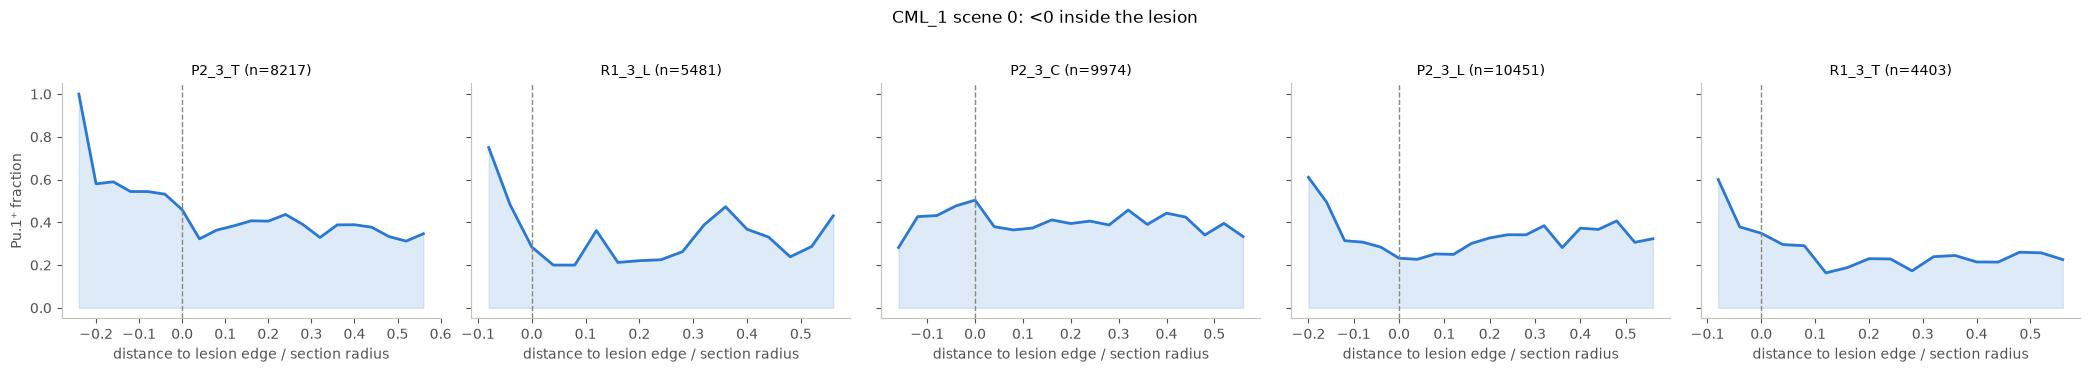

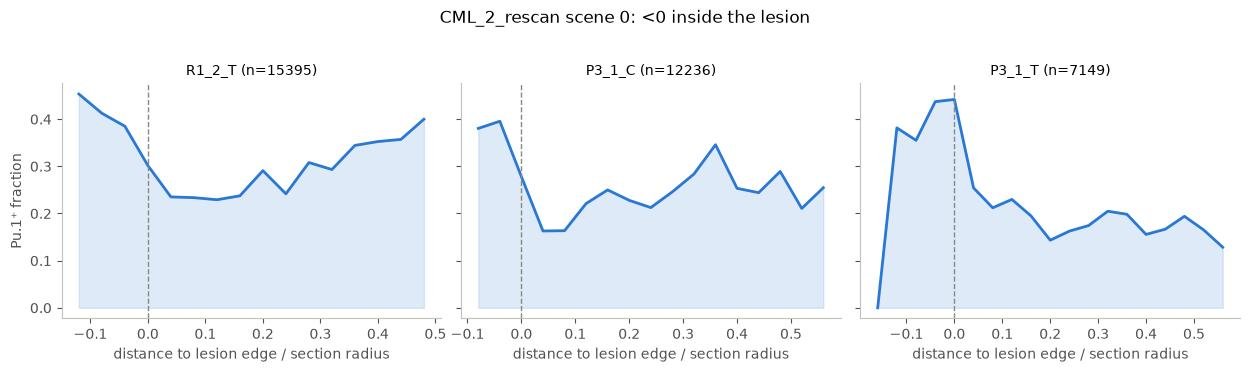

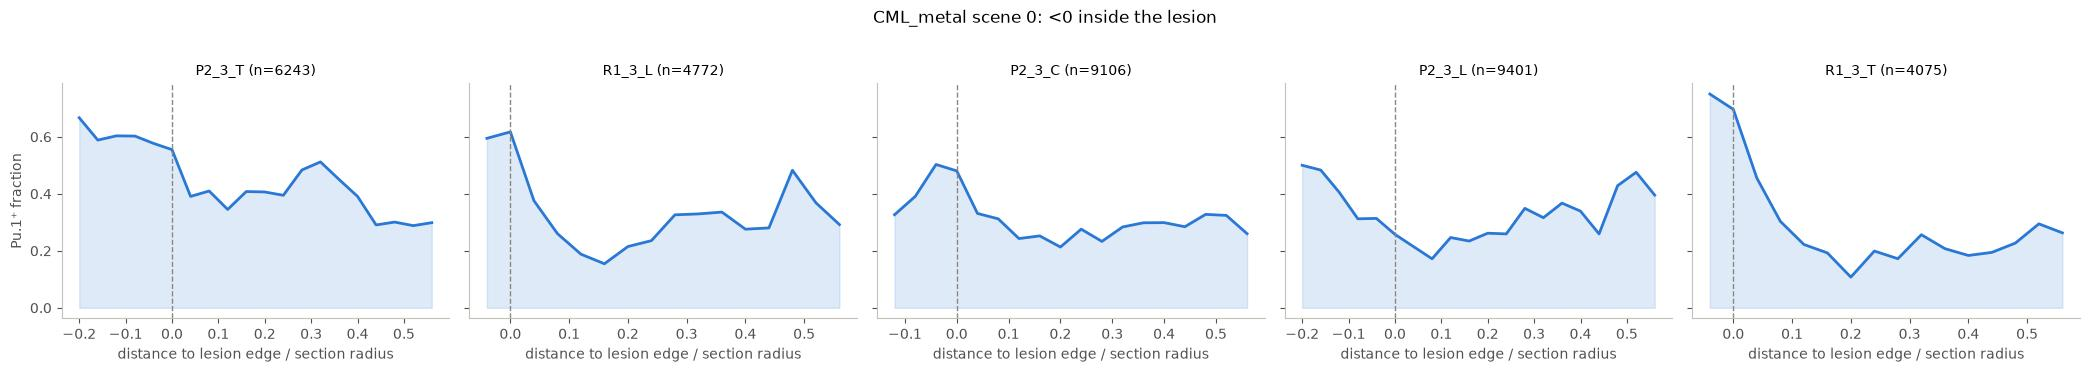

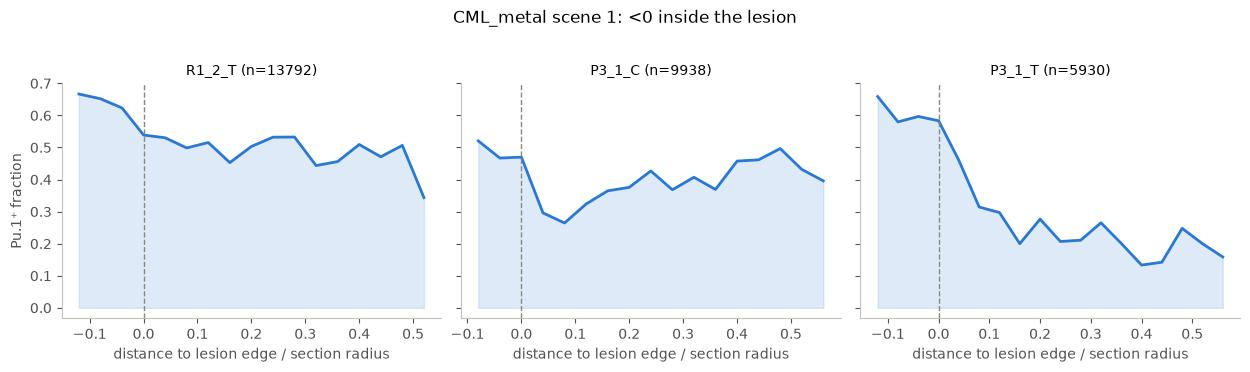

In [3]:
edges = np.arange(-0.3, 0.62, 0.04)
for r in runs:
    les = r.sections[r.sections.is_lesion_section].section_name.tolist()
    if not les:
        continue
    fig, axes = plt.subplots(1, len(les), figsize=(4.2 * len(les), 3.6), sharey=True, squeeze=False)
    for ax, sname in zip(axes.ravel(), les):
        c = r.cells[(r.cells.section_name == sname) & np.isfinite(r.cells.dist_to_lesion_rel)]
        b = pd.cut(c.dist_to_lesion_rel, edges)
        g = c.groupby(b, observed=False)
        frac = g["pu1_pos"].mean(); n = g.size()
        mids = [iv.mid for iv in frac.index]
        ax.plot(mids, frac.values, color="#2a78d6", lw=2)
        ax.fill_between(mids, 0, frac.values, color="#2a78d6", alpha=0.15)
        ax.axvline(0, color="#898781", ls="--", lw=1)
        ax.set_title(f"{sname} (n={len(c)})", fontsize=10)
        ax.set_xlabel("distance to lesion edge / section radius")
    axes[0, 0].set_ylabel("Pu.1⁺ fraction")
    fig.suptitle(f"{r.name}: <0 inside the lesion", y=1.02)
    plt.tight_layout(); plt.show()

## Where do the lesions sit? Radial position of Pu.1⁺ cells by zone

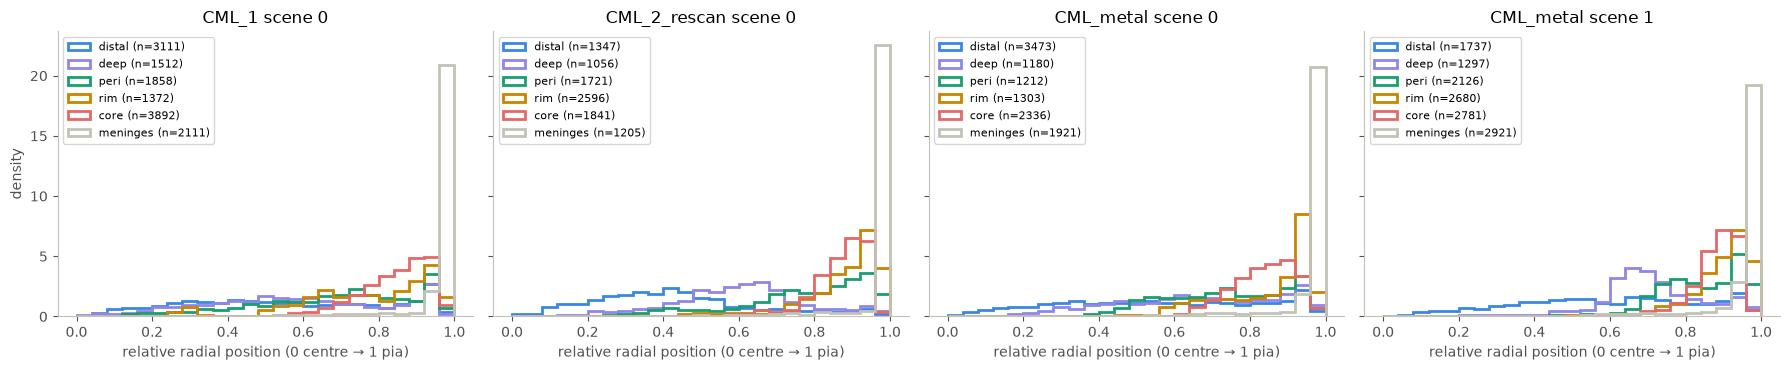

In [4]:
fig, axes = plt.subplots(1, len(runs), figsize=(4.5 * len(runs), 3.8), sharey=True, squeeze=False)
for ax, r in zip(axes.ravel(), runs):
    c = r.cells[r.cells.pu1_pos & r.cells.section_has_lesion]
    for z in R.ZONE_ORDER:
        s = c[c.zone == z].rel_pos.dropna()
        if len(s):
            ax.hist(s, bins=np.linspace(0, 1, 26), histtype="step", lw=2, color=R.ZONE_COLORS[z], label=f"{z} (n={len(s)})", density=True)
    ax.set_title(r.name); ax.set_xlabel("relative radial position (0 centre → 1 pia)"); ax.legend(fontsize=8)
axes[0, 0].set_ylabel("density")
plt.tight_layout()

## Zone composition of Pu.1⁺ cells per section

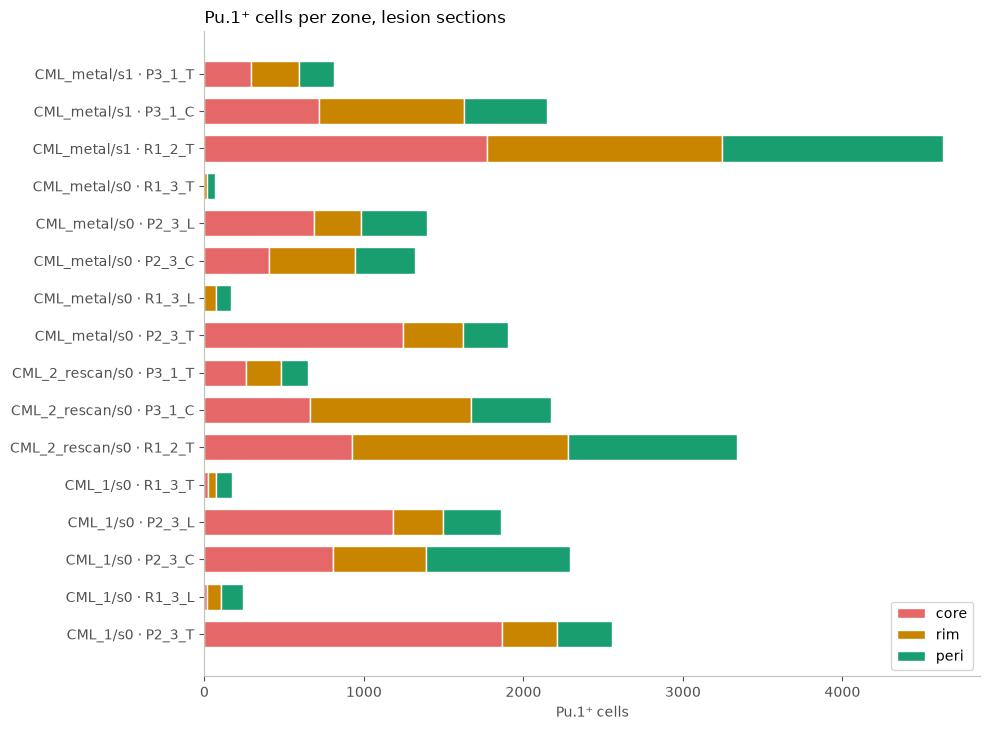

In [5]:
sec = R.sections_table(runs)
d = sec[sec.is_lesion_section].copy()
d["label"] = d.scene.str.replace(" scene ", "/s") + " · " + d.section_name.astype(str)
cols = {"core": "n_pu1_pos_core", "rim": "n_pu1_pos_rim", "peri": "n_pu1_pos_peri"}
fig, ax = plt.subplots(figsize=(10, 0.4 * len(d) + 1))
left = np.zeros(len(d))
for z, col in cols.items():
    ax.barh(d.label, d[col], left=left, color=R.ZONE_COLORS[z], label=z, height=0.7, edgecolor="white", linewidth=1)
    left += d[col].to_numpy()
ax.set_xlabel("Pu.1⁺ cells"); ax.legend(loc="lower right"); ax.set_title("Pu.1⁺ cells per zone, lesion sections", loc="left")
plt.tight_layout()

## Pu.1 and Iba1 intensity by zone (table channel means, per cell)

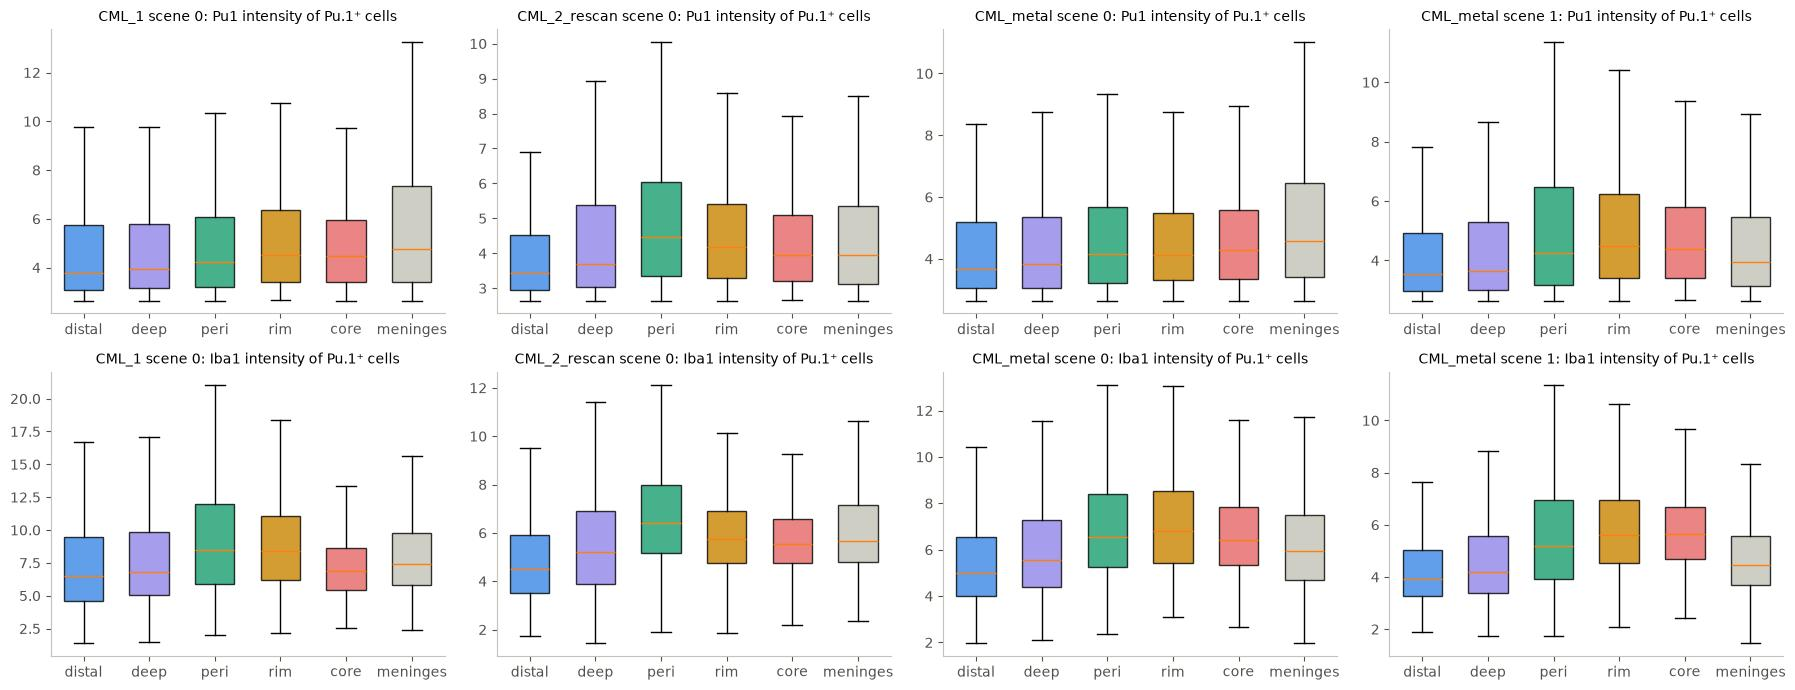

In [6]:
fig, axes = plt.subplots(2, len(runs), figsize=(4.5 * len(runs), 7), squeeze=False)
for j, r in enumerate(runs):
    c = r.cells[r.cells.pu1_pos & r.cells.section_has_lesion]
    for i, ch in enumerate(["Pu1_mean", "Iba1_mean"]):
        if ch not in c:
            continue
        data = [c.loc[c.zone == z, ch].dropna() for z in R.ZONE_ORDER]
        bp = axes[i, j].boxplot(data, showfliers=False, patch_artist=True, widths=0.6)
        axes[i, j].set_xticks(range(1, len(R.ZONE_ORDER) + 1), R.ZONE_ORDER)
        for patch, z in zip(bp["boxes"], R.ZONE_ORDER):
            patch.set_facecolor(R.ZONE_COLORS[z]); patch.set_alpha(0.8)
        axes[i, j].set_title(f"{r.name}: {ch.replace('_mean', '')} intensity of Pu.1⁺ cells", fontsize=10)
plt.tight_layout()